<a href="https://colab.research.google.com/github/AhmedEsammohmaed/Pretrained_model/blob/main/pretrain_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install system utilities for PDF handling
!apt-get update -y && !apt-get install -y poppler-utils

# 2. Install Python libraries for ML, Computer Vision, and Geometry Processing
!pip install -q transformers torch torchvision pillow opencv-python shapely accelerate pdf2image

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [113 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,188 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [44.3 kB]
Get:14

Loading pre-trained CubiCasa5K model from Hugging Face...


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Running pipeline on compute device: CPU

Upload ANY floor plan file (PDF, PNG, JPG, WEBP, TIFF, BMP):


Saving sample_floorplan.jpg to sample_floorplan.jpg

Processing received file: 'sample_floorplan.jpg'

--- INSTANCE SEGMENTATION OVERLAY ---


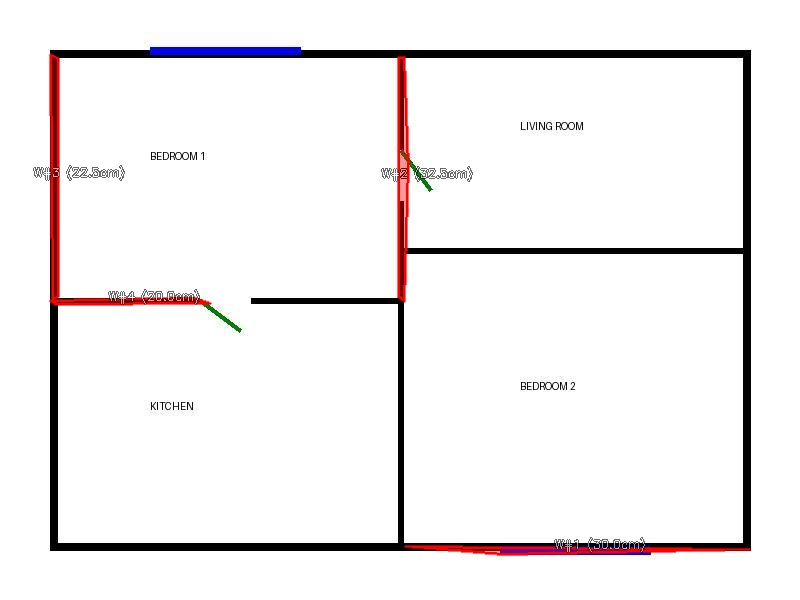


--- EXTRACTED BUILDING HIERARCHY JSON ---
{
    "Building": {
        "Walls": [
            {
                "id": "Wall #1",
                "geometry": [
                    [
                        405,
                        546
                    ],
                    [
                        503,
                        554
                    ],
                    [
                        749,
                        549
                    ]
                ],
                "thickness": "30.0 cm",
                "material": "Heavy Reinforced Concrete",
                "RF loss": "18.0 dB"
            },
            {
                "id": "Wall #2",
                "geometry": [
                    [
                        398,
                        57
                    ],
                    [
                        398,
                        296
                    ],
                    [
                        404,
                        301
         

In [6]:
import json
import os
import cv2
from IPython.display import display
from google.colab import files
import numpy as np
from pdf2image import convert_from_path
from PIL import Image
from shapely.geometry import Polygon
import torch
from transformers import (
    Mask2FormerForUniversalSegmentation,
    Mask2FormerImageProcessor,
)

# -------------------------------------------------------------------------
# 1. Configuration & Domain Logic
# -------------------------------------------------------------------------
PIXEL_TO_CM_SCALE = 2.5  # 1 pixel = 2.5 cm

COLOR_MAP = {
    "wall": (0, 0, 255),  # Red for Walls
    "room": (0, 255, 0),  # Green for Rooms
    "door": (255, 165, 0),  # Orange for Doors
    "window": (255, 255, 0),  # Cyan for Windows
}


def infer_rf_properties(thickness_cm):
  if thickness_cm >= 25:
    return {"material": "Heavy Reinforced Concrete", "rf_loss": "18.0 dB"}
  elif 12 <= thickness_cm < 25:
    return {"material": "Standard Concrete / Brick", "rf_loss": "10.5 dB"}
  elif 6 <= thickness_cm < 12:
    return {"material": "Drywall / Plasterboard", "rf_loss": "3.5 dB"}
  else:
    return {"material": "Glass / Thin Partition", "rf_loss": "2.0 dB"}


# -------------------------------------------------------------------------
# 2. Load Model into GPU/CPU Memory
# -------------------------------------------------------------------------
model_id = "phungpx/mask2former-swin-base-cubicassa"
print("Loading pre-trained CubiCasa5K model from Hugging Face...")
processor = Mask2FormerImageProcessor.from_pretrained(model_id)
model = Mask2FormerForUniversalSegmentation.from_pretrained(model_id)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running pipeline on compute device: {device.upper()}")
model.to(device)


# -------------------------------------------------------------------------
# 3. Processing & Visualization Function
# -------------------------------------------------------------------------
def process_and_draw_floorplan(
    image_input_path, output_vis_path="annotated_floorplan.jpg"
):
  pil_image = Image.open(image_input_path).convert("RGB")
  img_w, img_h = pil_image.size

  cv_img = cv2.imread(image_input_path)
  if cv_img is None:
    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

  overlay = cv_img.copy()

  inputs = processor(images=pil_image, return_tensors="pt").to(device)
  with torch.no_grad():
    outputs = model(**inputs)

  target_sizes = [(img_h, img_w)]
  results = processor.post_process_instance_segmentation(
      outputs, target_sizes=target_sizes
  )[0]

  segmentation_map = results["segmentation"].cpu().numpy()
  segments_info = results["segments_info"]
  id_to_label = model.config.id2label

  building_structure = {
      "Building": {"Walls": [], "Rooms": [], "Doors": [], "Windows": []}
  }

  wall_count = 0
  room_count = 0

  for info in segments_info:
    score = info["score"]
    if score < 0.35:
      continue

    label_name = id_to_label.get(info["label_id"], "unknown").lower()
    mask = (segmentation_map == info["id"]).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
      continue

    c = max(contours, key=cv2.contourArea)
    epsilon = 0.01 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, epsilon, True)
    polygon_pts = approx.reshape(-1, 2)

    if len(polygon_pts) < 3:
      continue

    pts_list = polygon_pts.tolist()
    poly = Polygon(pts_list)
    bbox = cv2.boundingRect(c)

    color = (200, 200, 200)
    label_text = ""

    if "wall" in label_name:
      wall_count += 1
      color = COLOR_MAP["wall"]
      thickness_px = min(bbox[2], bbox[3])
      thickness_cm = round(thickness_px * PIXEL_TO_CM_SCALE, 1)
      rf_data = infer_rf_properties(thickness_cm)

      building_structure["Building"]["Walls"].append({
          "id": f"Wall #{wall_count}",
          "geometry": pts_list,
          "thickness": f"{thickness_cm} cm",
          "material": rf_data["material"],
          "RF loss": rf_data["rf_loss"],
      })
      label_text = f"W#{wall_count} ({thickness_cm}cm)"

    elif any(
        k in label_name
        for k in ["room", "bedroom", "kitchen", "living", "bathroom"]
    ):
      room_count += 1
      color = COLOR_MAP["room"]
      area_m2 = round((poly.area * (PIXEL_TO_CM_SCALE**2)) / 10000, 2)

      building_structure["Building"]["Rooms"].append({
          "id": f"Room #{room_count}",
          "type": label_name.capitalize(),
          "polygon": pts_list,
          "area": f"{area_m2} m²",
      })
      label_text = f"{label_name.capitalize()} ({area_m2}m2)"

    elif "door" in label_name:
      color = COLOR_MAP["door"]
      building_structure["Building"]["Doors"].append(
          {"type": "Door", "bbox": bbox}
      )
      label_text = "Door"

    elif "window" in label_name:
      color = COLOR_MAP["window"]
      building_structure["Building"]["Windows"].append(
          {"type": "Window", "bbox": bbox}
      )
      label_text = "Window"

    cv2.fillPoly(overlay, [polygon_pts], color)
    cv2.polylines(
        cv_img, [polygon_pts], isClosed=True, color=color, thickness=2
    )

    M = cv2.moments(c)
    if M["m00"] != 0:
      cx = int(M["m10"] / M["m00"])
      cy = int(M["m01"] / M["m00"])
      cv2.putText(
          cv_img,
          label_text,
          (cx - 20, cy),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.4,
          (0, 0, 0),
          2,
      )
      cv2.putText(
          cv_img,
          label_text,
          (cx - 20, cy),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.4,
          (255, 255, 255),
          1,
      )

  cv2.addWeighted(overlay, 0.4, cv_img, 0.6, 0, cv_img)
  cv2.imwrite(output_vis_path, cv_img)
  return building_structure, output_vis_path


# -------------------------------------------------------------------------
# 4. Universal File Ingestion
# -------------------------------------------------------------------------
def prepare_image_for_model(uploaded_path):
  file_ext = os.path.splitext(uploaded_path)[1].lower()
  output_jpg = "ready_for_inference.jpg"

  if file_ext == ".pdf":
    pdf_pages = convert_from_path(uploaded_path)
    pdf_pages[0].convert("RGB").save(output_jpg, "JPEG")
  else:
    with Image.open(uploaded_path) as img:
      img.convert("RGB").save(output_jpg, "JPEG")

  return output_jpg


# -------------------------------------------------------------------------
# 5. Interactive Uploader Execution
# -------------------------------------------------------------------------
print("\nUpload ANY floor plan file (PDF, PNG, JPG, WEBP, TIFF, BMP):")
uploaded_files = files.upload()

if uploaded_files:
  raw_filename = list(uploaded_files.keys())[0]
  print(f"\nProcessing received file: '{raw_filename}'")

  standardized_image_path = prepare_image_for_model(raw_filename)
  extracted_json, visualization_path = process_and_draw_floorplan(
      standardized_image_path
  )

  print("\n--- INSTANCE SEGMENTATION OVERLAY ---")
  display(Image.open(visualization_path))

  print("\n--- EXTRACTED BUILDING HIERARCHY JSON ---")
  print(json.dumps(extracted_json, indent=4))

In [7]:
%%writefile app.py
import os
import json
import cv2
import numpy as np
from PIL import Image
from pdf2image import convert_from_path
from shapely.geometry import Polygon
import torch
import streamlit as st
from transformers import (
    Mask2FormerForUniversalSegmentation,
    Mask2FormerImageProcessor,
)

# -----------------------------------------------------------------------------
# 1. Page Configuration
# -----------------------------------------------------------------------------
st.set_page_config(
    page_title="Architectural RF Extractor",
    page_icon="🏗️",
    layout="wide",
)

st.title("🏗️ Architectural Floor Plan RF & Structural Pipeline")
st.caption("Automated extraction of structural hierarchies, wall thicknesses, and RF attenuation using Mask2Former.")

COLOR_MAP = {
    "wall": (0, 0, 255),      # Red (BGR)
    "room": (0, 255, 0),      # Green
    "door": (255, 165, 0),    # Orange
    "window": (255, 255, 0)   # Cyan
}

# -----------------------------------------------------------------------------
# 2. Model Caching
# -----------------------------------------------------------------------------
@st.cache_resource(show_spinner="Loading Hugging Face Model into RAM/GPU...")
def load_segmentation_model():
    model_id = "phungpx/mask2former-swin-base-cubicassa"
    processor = Mask2FormerImageProcessor.from_pretrained(model_id)
    model = Mask2FormerForUniversalSegmentation.from_pretrained(model_id)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    return processor, model, device

processor, model, device = load_segmentation_model()

# -----------------------------------------------------------------------------
# 3. Domain Logic & Processing Engine
# -----------------------------------------------------------------------------
def infer_rf_properties(thickness_cm):
    if thickness_cm >= 25:
        return {"material": "Heavy Reinforced Concrete", "rf_loss": "18.0 dB"}
    elif 12 <= thickness_cm < 25:
        return {"material": "Standard Concrete / Brick", "rf_loss": "10.5 dB"}
    elif 6 <= thickness_cm < 12:
        return {"material": "Drywall / Plasterboard", "rf_loss": "3.5 dB"}
    else:
        return {"material": "Glass / Thin Partition", "rf_loss": "2.0 dB"}

def process_and_draw_floorplan(pil_image, scale_cm_per_px, confidence_threshold):
    img_w, img_h = pil_image.size
    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    overlay = cv_img.copy()

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = [(img_h, img_w)]
    results = processor.post_process_instance_segmentation(outputs, target_sizes=target_sizes)[0]

    segmentation_map = results["segmentation"].cpu().numpy()
    segments_info = results["segments_info"]
    id_to_label = model.config.id2label

    building_structure = {
        "Building": {"Walls": [], "Rooms": [], "Doors": [], "Windows": []}
    }

    wall_count = 0
    room_count = 0

    for info in segments_info:
        score = info["score"]
        if score < confidence_threshold:
            continue

        label_name = id_to_label.get(info["label_id"], "unknown").lower()
        mask = (segmentation_map == info["id"]).astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        c = max(contours, key=cv2.contourArea)
        epsilon = 0.01 * cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, epsilon, True)
        polygon_pts = approx.reshape(-1, 2)

        if len(polygon_pts) < 3:
            continue

        pts_list = polygon_pts.tolist()
        poly = Polygon(pts_list)
        bbox = cv2.boundingRect(c)

        color = (200, 200, 200)
        label_text = ""

        if "wall" in label_name:
            wall_count += 1
            color = COLOR_MAP["wall"]
            thickness_px = min(bbox[2], bbox[3])
            thickness_cm = round(thickness_px * scale_cm_per_px, 1)
            rf_data = infer_rf_properties(thickness_cm)

            building_structure["Building"]["Walls"].append({
                "id": f"Wall #{wall_count}",
                "geometry": pts_list,
                "thickness": f"{thickness_cm} cm",
                "material": rf_data["material"],
                "RF loss": rf_data["rf_loss"]
            })
            label_text = f"W#{wall_count} ({thickness_cm}cm)"

        elif any(k in label_name for k in ["room", "bedroom", "kitchen", "living", "bathroom"]):
            room_count += 1
            color = COLOR_MAP["room"]
            area_m2 = round((poly.area * (scale_cm_per_px ** 2)) / 10000, 2)

            building_structure["Building"]["Rooms"].append({
                "id": f"Room #{room_count}",
                "type": label_name.capitalize(),
                "polygon": pts_list,
                "area": f"{area_m2} m²"
            })
            label_text = f"{label_name.capitalize()} ({area_m2}m2)"

        elif "door" in label_name:
            color = COLOR_MAP["door"]
            building_structure["Building"]["Doors"].append({"type": "Door", "bbox": bbox})
            label_text = "Door"

        elif "window" in label_name:
            color = COLOR_MAP["window"]
            building_structure["Building"]["Windows"].append({"type": "Window", "bbox": bbox})
            label_text = "Window"

        cv2.fillPoly(overlay, [polygon_pts], color)
        cv2.polylines(cv_img, [polygon_pts], isClosed=True, color=color, thickness=2)

        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(cv_img, label_text, (cx - 20, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 2)
            cv2.putText(cv_img, label_text, (cx - 20, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    cv2.addWeighted(overlay, 0.4, cv_img, 0.6, 0, cv_img)
    annotated_pil = Image.fromarray(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))

    return building_structure, annotated_pil

# -----------------------------------------------------------------------------
# 4. Streamlit UI Layout
# -----------------------------------------------------------------------------
with st.sidebar:
    st.header("⚙️ Configuration")
    scale_cm_per_px = st.slider("Scale: Pixel to CM Ratio", 0.5, 10.0, 2.5, 0.1)
    confidence_threshold = st.slider("Detection Threshold", 0.1, 0.9, 0.35, 0.05)

uploaded_file = st.file_uploader("Upload Architectural Floor Plan (PDF, PNG, JPG, WEBP):", type=["pdf", "png", "jpg", "jpeg", "webp"])

if uploaded_file is not None:
    if uploaded_file.name.lower().endswith(".pdf"):
        with open("temp_upload.pdf", "wb") as f:
            f.write(uploaded_file.getbuffer())
        images = convert_from_path("temp_upload.pdf")
        raw_image = images[0].convert("RGB")
    else:
        raw_image = Image.open(uploaded_file).convert("RGB")

    if st.button("🚀 Analyze Floor Plan", type="primary"):
        with st.spinner("Processing segmentation & calculating RF parameters..."):
            json_output, annotated_image = process_and_draw_floorplan(raw_image, scale_cm_per_px, confidence_threshold)

        st.success("Analysis Complete!")
        col1, col2 = st.columns(2)
        with col1:
            st.subheader("Original Blueprint")
            st.image(raw_image, use_container_width=True)
        with col2:
            st.subheader("Segmentation Overlay")
            st.image(annotated_image, use_container_width=True)

        st.divider()
        st.subheader("📊 Extracted Structural Hierarchy JSON")
        st.download_button(
            label="💾 Download JSON File",
            data=json.dumps(json_output, indent=4),
            file_name=f"{os.path.splitext(uploaded_file.name)[0]}_structure.json",
            mime="application/json"
        )
        st.json(json_output)

Writing app.py


In [11]:
# 1. Download Cloudflare Tunnel binary
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 2. Run Streamlit and expose it via Cloudflare in the background
import subprocess
import time

# Start Streamlit
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# Start Cloudflare Tunnel
tunnel = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Wait 5 seconds for the tunnel to establish
time.sleep(5)

# Read the generated trycloudflare.com URL from logs
import re
for line in iter(tunnel.stderr.readline, b''):
    log_line = line.decode('utf-8')
    if "trycloudflare.com" in log_line:
        match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', log_line)
        if match:
            print("\n=======================================================")
            print("🚀 YOUR STREAMLIT APP IS LIVE AT THIS LINK:")
            print(match.group(0))
            print("=======================================================\n")
            break


🚀 YOUR STREAMLIT APP IS LIVE AT THIS LINK:
https://outreach-topics-billion-side.trycloudflare.com

